# Capstone: Define and Solve an ML Problem

In [3]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

import scipy.stats as stats


I0000 00:00:1784855753.599861   12887 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784855766.694148   12887 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [12]:
import pandas as pd

# Column names (the raw UCI file has no header row)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
           'income_binary']

df = pd.read_csv(
    'adult.data',
    names=columns,
    skipinitialspace=True,   # strips the leading space before each value
    na_values='?'            # UCI uses '?' for missing values, not NaN
)

df['income_binary'] = df['income_binary'].str.strip()

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [13]:
# File paths for both data sets
# census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
# airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# # Load your chosen dataset and save it to df
# df = pd.read_csv(census_filename) # YOUR CODE HERE

df.rename(columns={'income': 'income_binary'}, inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income_binary   32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

<Double click this Markdown cell to make it editable, and record your answers here.>
1. I chose the census dataset.
2. My label is binary income which contains two values: <=50K and >50K. I am trying to predict whether an individual income exceeds \$50,000
3. I plan to use (answer later)
4. This matters because organizations that extend credit, such as banks or lending platforms, need to assess a potential borrower's ability to repay before approving a loan. A model that predicts whether an individual's income exceeds $50,000 can serve as one input into a broader credit risk model, helping a bank estimate a customer's affordability and repayment capacity. This can inform lending decisions such as how much credit to extend or what interest rate to offer, allowing the business to reduce default risk while still serving creditworthy customers who might otherwise be overlooked.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [14]:
y = df["income_binary"]
class_imbalance = y.value_counts(normalize=True) * 100
class_imbalance

income_binary
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

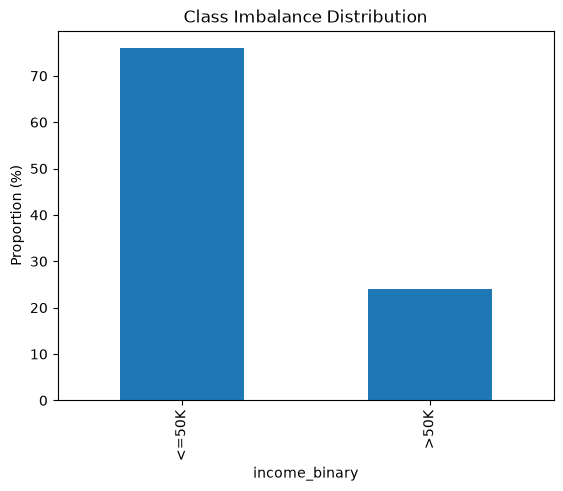

In [15]:
class_imbalance.plot(kind='bar', title="Class Imbalance Distribution")
plt.ylabel('Proportion (%)')
plt.show()

Income ```<=50K``` is ```~76 %``` of the class label while Income ```>50K``` is ```~24%``` (about one-third)  of the class label.

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [16]:
X = df.drop("income_binary", axis="columns")
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
dtypes: int64(6), str(8)
memory usage: 3.5 MB


In [17]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [18]:
X.describe(exclude=["int64", "float64"])

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,30725,32561,32561,30718,32561,32561,32561,31978
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,22696,10501,14976,4140,13193,27816,21790,29170


In [19]:
### Handle Outliers and Missing Values in Numeric columns 

### Missing values:
# Numeric columns
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

## Handling Missing Values
cols_with_missing_vals = df[numeric_cols].describe(include="all").loc["count"] < df.shape[0]

print(cols_with_missing_vals)
cols_with_missing_vals = cols_with_missing_vals[cols_with_missing_vals].index

for col in cols_with_missing_vals:
    median_val = df[col].describe().loc["50%"]
    df[col].fillna(median_val, inplace=True)

for col in numeric_cols:
    df[col] = stats.mstats.winsorize(df[col], limits=[0.01, 0.01])

df[numeric_cols].info() # found no missing values in numeric columns


age               False
fnlwgt            False
education-num     False
capital-gain      False
capital-loss      False
hours-per-week    False
Name: count, dtype: bool
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   fnlwgt          32561 non-null  int64
 2   education-num   32561 non-null  int64
 3   capital-gain    32561 non-null  int64
 4   capital-loss    32561 non-null  int64
 5   hours-per-week  32561 non-null  int64
dtypes: int64(6)
memory usage: 1.5 MB


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income_binary   32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [21]:
### Handle Missing Values in Category columns 

## category columns:
category_cols = df.select_dtypes(exclude=["float64", "int64"]).columns

# df[category_cols].info()
## found mising values

## Handling Missing Values
cols_with_missing_vals = df[category_cols].describe(include="all").loc["count"] < df.shape[0]

cols_with_missing_vals = cols_with_missing_vals[cols_with_missing_vals].index


for col in cols_with_missing_vals:
    mode = df[col].describe(include="all").loc["top"]
    df[col] = df[col].fillna(mode)

df.info() # No more missing values



<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income_binary   32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [22]:
## Feature Imbalance Proportion
for col in category_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100) 


workclass:
workclass
Private             75.341666
Self-emp-not-inc     7.803814
Local-gov            6.427935
State-gov            3.986364
Self-emp-inc         3.427413
Federal-gov          2.948312
Without-pay          0.042996
Never-worked         0.021498
Name: proportion, dtype: float64

education:
education
HS-grad         32.250238
Some-college    22.391818
Bachelors       16.446055
Masters          5.291607
Assoc-voc        4.244341
11th             3.608612
Assoc-acdm       3.276926
10th             2.865391
7th-8th          1.983969
Prof-school      1.768987
9th              1.578576
12th             1.329812
Doctorate        1.268389
5th-6th          1.022696
1st-4th          0.515955
Preschool        0.156629
Name: proportion, dtype: float64

marital-status:
marital-status
Married-civ-spouse       45.993673
Never-married            32.809189
Divorced                 13.645158
Separated                 3.147938
Widowed                   3.049661
Married-spouse-absent     1

In [23]:
# df['age'] = pd.to_numeric(df['age'], errors='coerce')
# df['hours-per-week'] = pd.to_numeric(df['hours-per-week'], errors='coerce')

In [24]:
df["fnlwgt"]

0         77516
1         83311
2        215646
3        234721
4        338409
          ...  
32556    257302
32557    154374
32558    151910
32559    201490
32560    287927
Name: fnlwgt, Length: 32561, dtype: int64

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income_binary   32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [27]:
# YOUR CODE HERE
## feature engineering techniques such as one-hot encoding on categorical features
df.head()

for col in category_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)


workclass:
workclass
Private             75.341666
Self-emp-not-inc     7.803814
Local-gov            6.427935
State-gov            3.986364
Self-emp-inc         3.427413
Federal-gov          2.948312
Without-pay          0.042996
Never-worked         0.021498
Name: proportion, dtype: float64

education:
education
HS-grad         32.250238
Some-college    22.391818
Bachelors       16.446055
Masters          5.291607
Assoc-voc        4.244341
11th             3.608612
Assoc-acdm       3.276926
10th             2.865391
7th-8th          1.983969
Prof-school      1.768987
9th              1.578576
12th             1.329812
Doctorate        1.268389
5th-6th          1.022696
1st-4th          0.515955
Preschool        0.156629
Name: proportion, dtype: float64

marital-status:
marital-status
Married-civ-spouse       45.993673
Never-married            32.809189
Divorced                 13.645158
Separated                 3.147938
Widowed                   3.049661
Married-spouse-absent     1

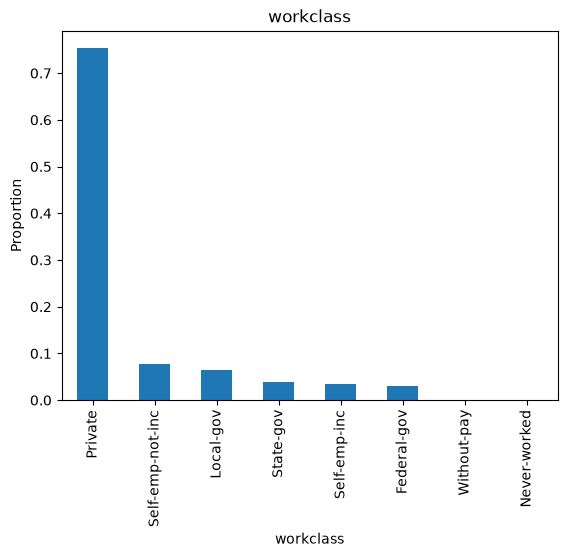

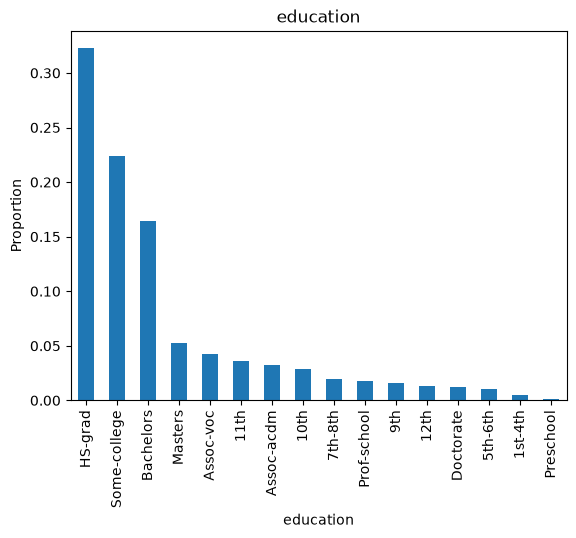

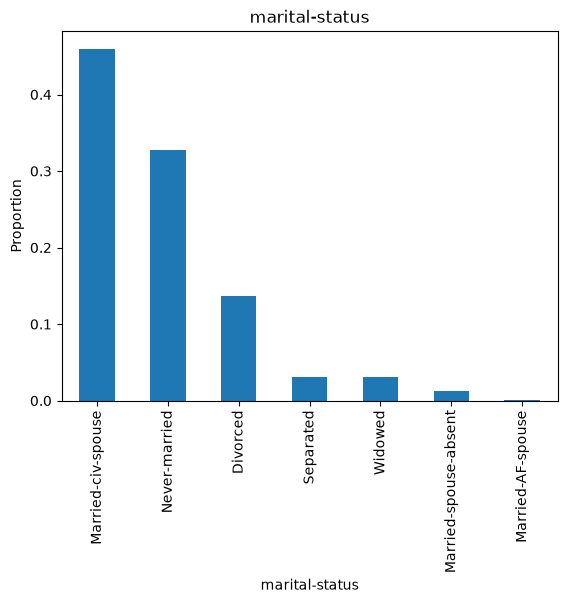

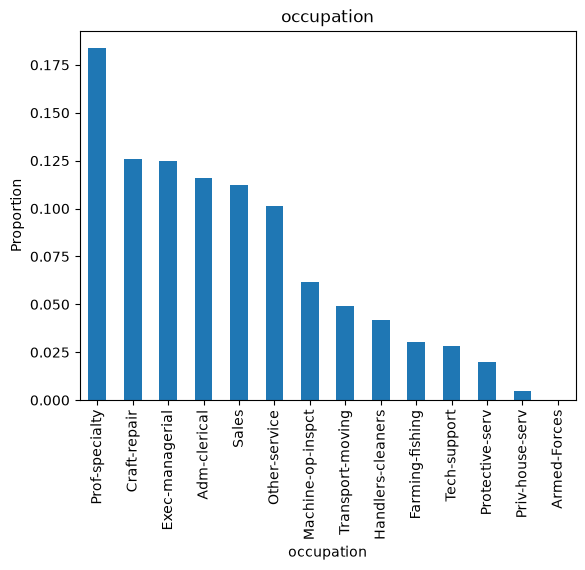

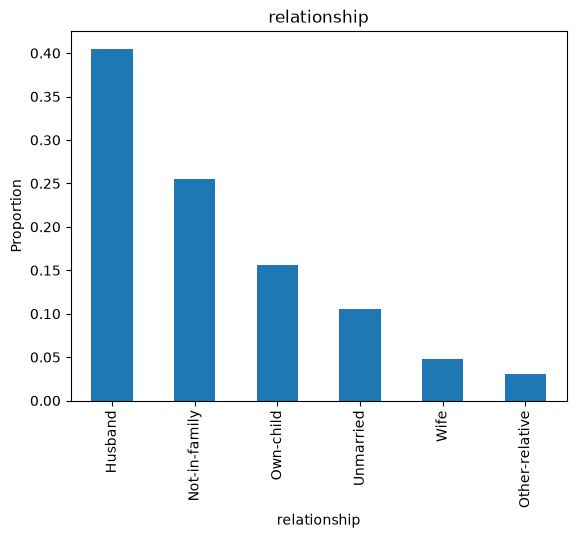

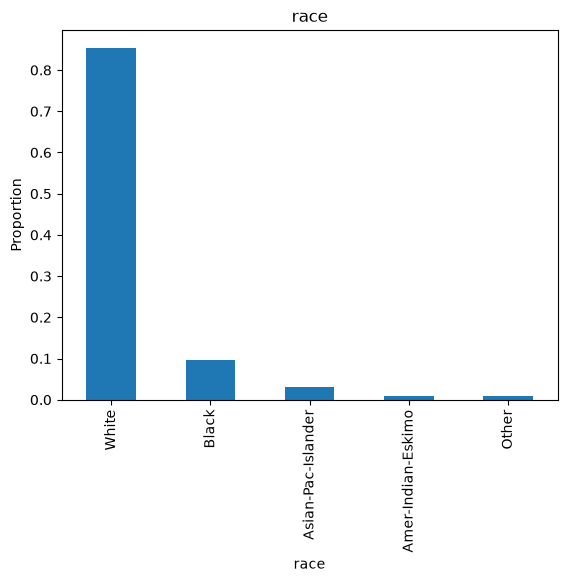

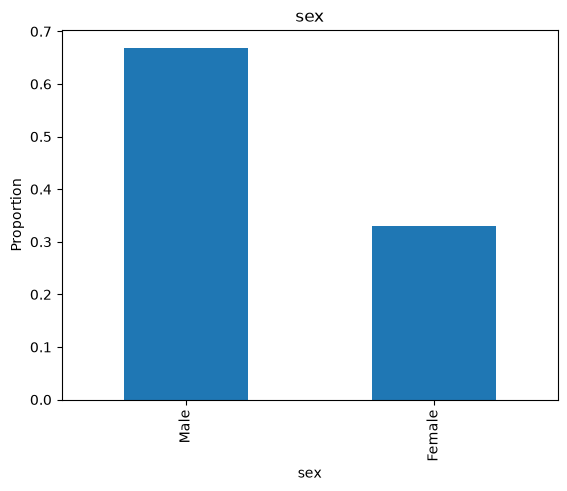

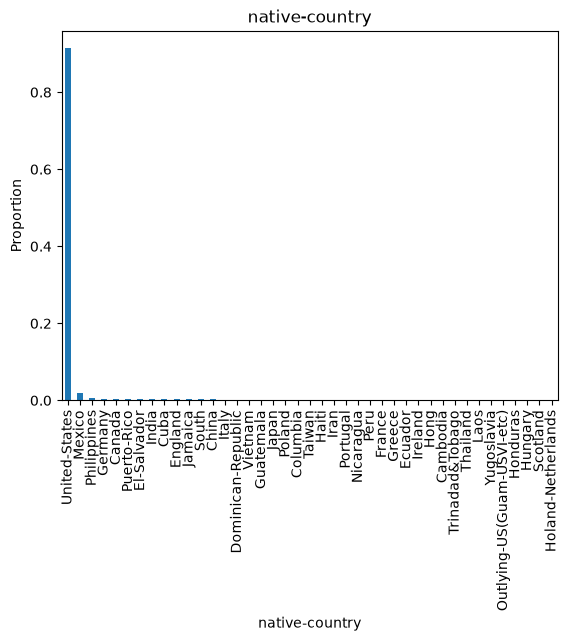

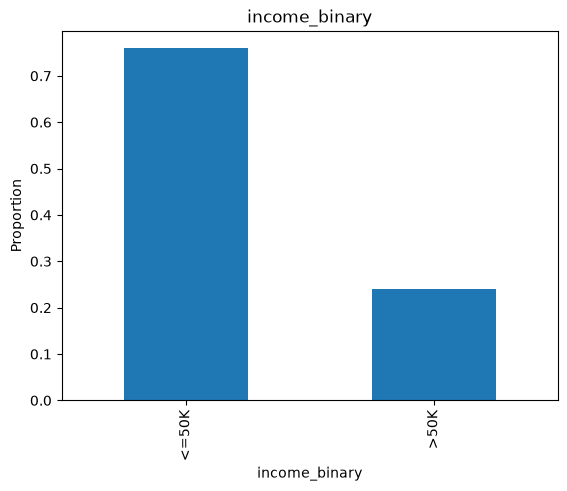

In [29]:
## plotting the proportion of unique values
import matplotlib.pyplot as plt

for col in category_cols:
    df[col].value_counts(normalize=True).plot(kind='bar', title=col)
    plt.ylabel('Proportion')
    plt.show()

In [30]:
corr_matrix = df.corr()
corr_matrix

ValueError: could not convert string to float: 'State-gov'

In [31]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

NameError: name 'corr_matrix' is not defined

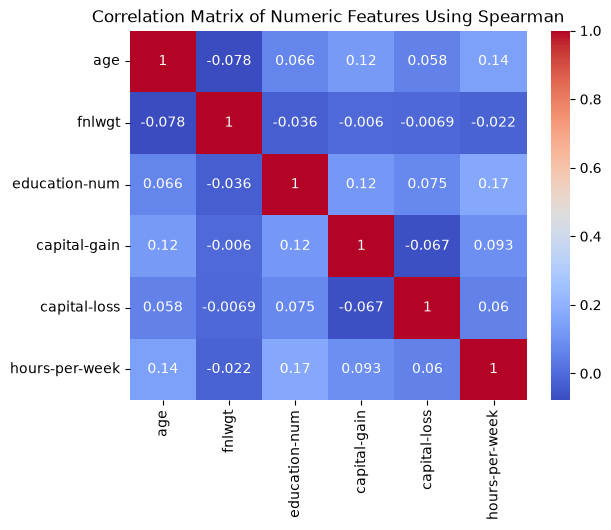

In [32]:
corr_mat_spearman = df[numeric_cols].corr(method="spearman")
sns.heatmap(corr_mat_spearman, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features Using Spearman")
plt.show()

/tmp/ipykernel_12887/1549737231.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


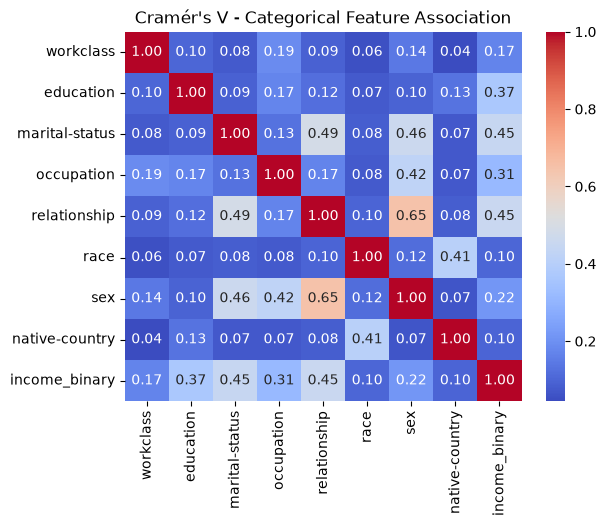

In [33]:
def cramers_v(col1, col2):
    contingency = pd.crosstab(col1, col2)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = df.select_dtypes(include="object").columns

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cramér's V - Categorical Feature Association")
plt.show()

In [34]:
df.drop(columns=["education"], inplace=True)

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
X_numeric = add_constant(df[numeric_cols])

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

vif_data = vif_data[vif_data["feature"] != "const"]
vif_data.sort_values("VIF", ascending=False)

,feature,VIF
3,education-num,1.058696
4,capital-gain,1.057238
6,hours-per-week,1.037185
1,age,1.029650
5,capital-loss,1.017388
2,fnlwgt,1.008020


### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. There is a strong association between sex, relationship and marital status. Relationship and sex has association of ```0.65```, which makes sense since the unique values are ```Husband``` and ```Wife```, ```Unmarried``` so one of these columns may be redundant. Also notable: relationship and marital-status at ```0.49```, and marital-status and sex_selfID at ```0.42``` — all three of these columns overlap conceptually, which is worth flagging as a multicollinearity risk.
2. Among the numerical variables, there is correlation worth flagging.
3. I dropped education since education-num already quantifies education level.
4. I replaced missing numeric values with their median, and misisng categorical values with their mode.
5. I winsorized the outliers for numeric features.
6. I plan to randomly sample the data so I can fix the imbalance between the income binary label.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. - This dataset comes from 1990s U.S. Census data, so it reflects the demographics and labor market of a specific country and era rather than a current or global picture of income. The data is also heavily skewed: most individuals are White, U.S.-born, and the sex field is captured as a simple binary that erases non-binary identities. Because of this imbalance, a model trained on it will likely be less reliable for underrepresented racial groups, non-U.S.-born individuals, and anyone outside the binary gender framing. The income label itself is also skewed toward <=50K, which risks the model favoring the majority class and reflects real, historically-rooted income disparities rather than a neutral ground truth. 

 - Several features could also act as proxies for protected characteristics even if race is removed. relationship and marital-status correlate strongly with sex_selfID (confirmed earlier via Cramer's V), effectively re-encoding gender. native-country can proxy for race or immigration status, and education/occupation reflect historical inequities in access shaped by race, gender, and socioeconomic background, so the model isn't just predicting "merit," it's partly reproducing structural patterns already in the data.

2. If used in a lending context, the people most at risk are those the model is wrong about, particularly members of underrepresented groups in this dataset. These include: racial minorities, non-U.S.-born individuals, and women, whose patterns the model has seen far less of and is more likely to misjudge. A false negative (predicting someone earns <=50K when they actually earn more) could mean a creditworthy person is denied a loan or offered worse terms they didn't deserve, cutting them off from opportunities like homeownership or business investment. A false positive (predicting >50K when someone earns less) could mean approving debt for someone who genuinely can't afford it, pushing them toward default, damaged credit, and financial hardship. For the business itself, this also carries real legal and reputational risk, since lending decisions that disproportionately harm protected groups can violate fair lending laws even without any explicit intent to discriminate.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [38]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder

y = df["income_binary"]

# drop the income_binary and relationship columns
X = df.drop(columns=["income_binary", "relationship"])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat_encoder", OneHotEncoder(drop="first", sparse_output=False), make_column_selector(dtype_include="object"))
    ],
    remainder=StandardScaler()
)
X_encoded = preprocessor.fit_transform(X)

In [39]:
y_encoded = y.map({"<=50K": 0, ">50K": 1})

In [41]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

encoder = preprocessor.named_transformers_["cat_encoder"]
cat_feature_names = encoder.get_feature_names_out(cat_cols)

all_feature_names = list(cat_feature_names) + num_cols
X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names)
X_encoded_df.head()

/tmp/ipykernel_12887/610009469.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.034988,-1.113416,1.142699,0.610928,-0.218828,-0.032700
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.850963,-1.055313,1.142699,-0.251406,-0.218828,-2.294188
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,-0.039191,0.271533,-0.427466,-0.251406,-0.218828,-0.032700
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.073501,0.462787,-1.212549,-0.251406,-0.218828,-0.032700
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,-0.780986,1.502406,1.142699,-0.251406,-0.218828,-0.032700


In [42]:
# YOUR CODE HERE


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. I dropped the relationship, and earlier, I had dropped the education column. The relationship column is redundant given the association it has with sex and marital status. Also, the education is only a qualitative form of education-num. education-num is numerical hence great for modelling. Other features are kept for modeling. I can run a feature selection to see what combination of features will be great for my model.

2. I used standard scaler becuase it is good as a preprocessing step before using in ML models. Although it matters for KNN, using a standardized dataset does not affect Decision Trees since standardizing is just a transformation and doesn't change how the tree performs.


## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [43]:
# Create labeled examples from the dataset
# YOUR CODE HERE

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [44]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
train_df = pd.DataFrame(X_train)
train_df["label"] = y_train.values

majority = train_df[train_df["label"] == 0]
minority = train_df[train_df["label"] == 1]

# Adjusting the label imbalance
majority_downsampled = majority.sample(n=len(minority), random_state=42)
balanced_train = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_train.drop(columns=["label"])
y_train_balanced = balanced_train["label"]

X_train, y_train = X_train_balanced, y_train_balanced
y_train.value_counts()

label
0    6273
1    6273
Name: count, dtype: int64

In [45]:
# Train, test and evaluate your model
# YOUR CODE HERE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.807616,0.678800
1,Decision Tree,0.771227,0.621058
2,KNN,0.785352,0.657689


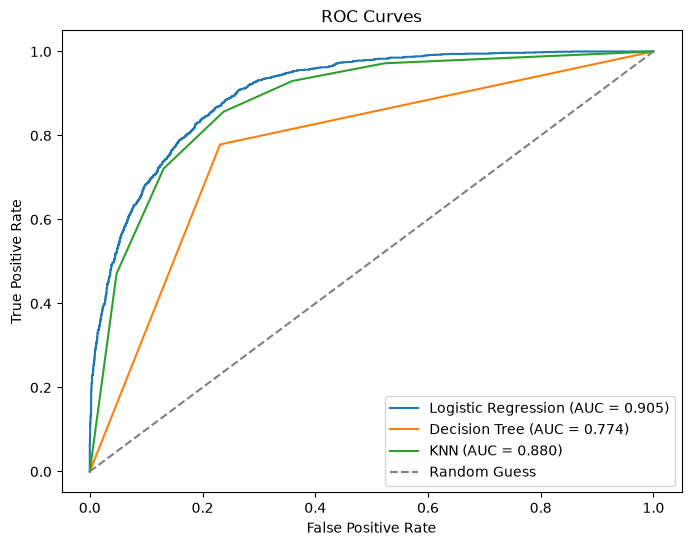

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [47]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc_score = roc_auc_score(y_test, y_proba)
    
    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1, "AUC": auc_score})

results_df = pd.DataFrame(results)

In [48]:
results_df

,Model,Accuracy,F1 Score,AUC
0,Logistic Regression,0.807616,0.678800,0.905136
1,Decision Tree,0.771227,0.621058,0.773778
2,KNN,0.785352,0.657689,0.879761


In [49]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]  # supports both l1 and l2 penalties
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV AUC score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 ins

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC score: 0.9043504073389179


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [50]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, pos_label=1)
final_auc = roc_auc_score(y_test, y_proba_final)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Accuracy: {final_accuracy:.3f}")
print(f"F1 Score: {final_f1:.3f}")
print(f"AUC: {final_auc:.3f}")

Best hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.807
F1 Score: 0.679
AUC: 0.905


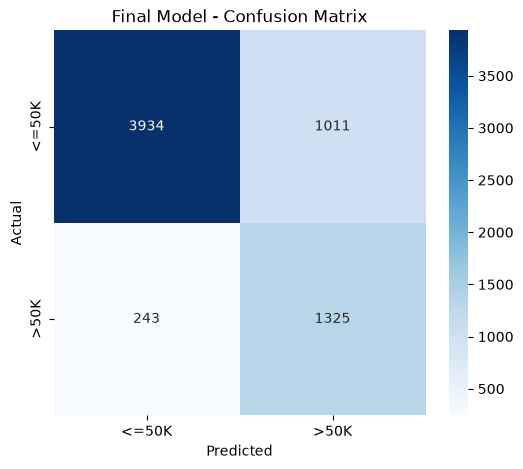

,Predicted <=50K,Predicted >50K
Actual <=50K,3934,1011
Actual >50K,243,1325


In [51]:
# Interpret your model's outputs 
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

cm_df = pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model - Confusion Matrix") 
plt.show()

cm_df

In [52]:
tn, fp, fn, tp = cm.ravel()

total = cm.sum()

# calculating percentage within each actual class
cm_percent_row = pd.DataFrame(
    [[f"TN = {tn/(tn+fp):.1%}", f"FP = {fp/(tn+fp):.1%}"],
     [f"FN = {fn/(fn+tp):.1%}", f"TP = {tp/(fn+tp):.1%}"]],
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
cm_percent_row

,Predicted <=50K,Predicted >50K
Actual <=50K,TN = 79.6%,FP = 20.4%
Actual >50K,FN = 15.5%,TP = 84.5%


In [53]:
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": final_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
8,marital-status_Married-civ-spouse,2.210683
7,marital-status_Married-AF-spouse,2.032781
52,native-country_Jamaica,1.003665
74,capital-gain,0.867639
15,occupation_Exec-managerial,0.787631
...,...,...
6,workclass_Without-pay,-1.062341
69,native-country_Vietnam,-1.097097
16,occupation_Farming-fishing,-1.272094
64,native-country_South,-1.476171


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

<Double click this Markdown cell to make it editable, and record your answers here.>

1. I chose Logistic Regression (test split of 20%) because it had the highest accuracy, F1 score and Decision Tree consistently. The results are stable. I tested using different test splits (20%, 30%, 40%) and Logistic regression outperformed KNN and DecisionTrees. I ran the code several times so results for 0.2 in the notebook may be slightly off by floating point values.

| Test Size | Model | Accuracy | F1 Score | AUC |
|-----------|-------|----------|----------|-----|
| 20% | Logistic Regression | 0.807 | 0.681 | 0.907 |
| &nbsp; | Decision Tree | 0.774 | 0.622 | 0.773 |
| &nbsp; | KNN | 0.786 | 0.658 | 0.881 |
| 30% | Logistic Regression | 0.807 | 0.681 | 0.907 |
| &nbsp; | Decision Tree | 0.771 | 0.618 | 0.770 |
| &nbsp; | KNN | 0.788 | 0.661 | 0.882 |
| 40% | Logistic Regression | 0.806 | 0.676 | 0.904 |
| &nbsp; | Decision Tree | 0.771 | 0.621 | 0.773 |
| &nbsp; | KNN | 0.781 | 0.651 | 0.874 |

2. Comparing accuracy, F1, and AUC together showed that accuracy alone can be misleading on this imbalanced dataset i.e a model could score highly just by favoring the majority class. AUC proved to be the more reliable metric for comparing models, especially since I trained on a class-balanced training set but evaluated on the original imbalanced test distribution, which affects metrics computed at a single decision threshold. I also learned that hyperparameter tuning with GridSearchCV and that testing across multiple train/test splits was a useful way to confirm the model ranking was stable rather than an artifact of one split.

3. Each coefficient shows whether a feature makes the model more or less likely to predict that someone earns ```>50K```. A positive coefficient pushes the prediction toward higher income, and a negative coefficient pushes it toward lower income. The strongest positive predictors were marital status, especially being married, along with capital gain and working in an executive or managerial role. This suggests that being married and having investment income or a management position are strongly linked to higher earnings in this dataset. The strongest negative predictors were occupations such as private household service and farming or fishing, along with working without pay. These tend to be lower paying types of work, so the result lines up with what we would expect. One pattern worth noting is that a person's native country showed up among the most influential features, in both directions. This connects to a fairness concern raised earlier, since where someone was born should not meaningfully determine their predicted income in the U.S, yet the model treats it as a strong signal. It is also worth mentioning that many countries are represented by very few people in this dataset, so these particular results may not be reliable or generalizable.


4.  Yes. In the results, the model is biased towards False Positives than False Negatives, meaning it's much more likely to prediict ```>50K``` for someone who is actually ```<50K``` than to miss someone who is actually ```>50K```. So, ```20.5%``` of actual low earners get misclassified as high earners, while only 15.4% of actual high earners get misclassified. The model is notably better at catching True Positives than catching True Negatives, which was a concern earlier regarding underrespresented groups in features like race and sex that may cause bias in the model.  

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [54]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [55]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: Two hidden layers with 32 and 16 units, both using ReLU activation.
# ReLU is the standard choice for hidden layers since it trains efficiently and
# avoids the vanishing gradient problem common with sigmoid/tanh activations.
# 32 units in the first layer gives the network enough capacity to learn patterns
# across our encoded features, and narrowing to 16 units in the second layer
# creates a funnel shape that gradually compresses what's been learned toward
# the final prediction, without over-complicating the model for this dataset size.
nn_model.add(keras.layers.Dense(32, activation="relu"))
nn_model.add(keras.layers.Dense(16, activation="relu"))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# A single unit with sigmoid activation outputs a probability between 0 and 1,
# representing the predicted likelihood of the positive class (income >50K).
nn_model.add(keras.layers.Dense(1, activation="sigmoid"))

# Print a summary of your model
nn_model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1784856850.163749   12887 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,041 (11.88 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 0 (0.00 B)

### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [56]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# A learning rate of 0.01 is a reasonable starting point for plain SGD. It's higher
# than typical defaults for adaptive optimizers like Adam, since SGD doesn't scale
# gradients automatically, but not so high that training becomes unstable or
# overshoots the minimum. 
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [57]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [58]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=["accuracy"])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [59]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [60]:
t0 = time.time()  # start time

# Decision: 50 epochs. With a balanced training set, a simple
# two-hidden-layer network, and SGD with a moderate learning rate (0.01), 50 epochs
# gives the model enough passes over the data to converge without taking excessively
# long to train. We'll check the validation loss/accuracy curves afterward to see if
# this was enough.
num_epochs = 50

logger = ProgBarLoggerNEpochs(num_epochs=num_epochs, every_n=5)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=num_epochs,
    callbacks=[logger],
    verbose=0
)

t1 = time.time()  # stop time
print('Elapsed time: %.2fs' % (t1 - t0))

Epoch [5/ 50], Accuracy: 0.8226, Loss: 0.3902, Val_accuracy: 0.7988, Val_loss: 0.4278
Epoch [10/ 50], Accuracy: 0.8312, Loss: 0.3688, Val_accuracy: 0.8068, Val_loss: 0.4175
Epoch [15/ 50], Accuracy: 0.8353, Loss: 0.3595, Val_accuracy: 0.8116, Val_loss: 0.4150
Epoch [20/ 50], Accuracy: 0.8367, Loss: 0.3539, Val_accuracy: 0.8112, Val_loss: 0.4147
Epoch [25/ 50], Accuracy: 0.8396, Loss: 0.3494, Val_accuracy: 0.8116, Val_loss: 0.4165
Epoch [30/ 50], Accuracy: 0.8383, Loss: 0.3458, Val_accuracy: 0.8124, Val_loss: 0.4168
Epoch [35/ 50], Accuracy: 0.8420, Loss: 0.3424, Val_accuracy: 0.8116, Val_loss: 0.4196
Epoch [40/ 50], Accuracy: 0.8430, Loss: 0.3401, Val_accuracy: 0.8143, Val_loss: 0.4212
Epoch [45/ 50], Accuracy: 0.8455, Loss: 0.3376, Val_accuracy: 0.8104, Val_loss: 0.4233
Epoch [50/ 50], Accuracy: 0.8439, Loss: 0.3353, Val_accuracy: 0.8096, Val_loss: 0.4244
Elapsed time: 33.99s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



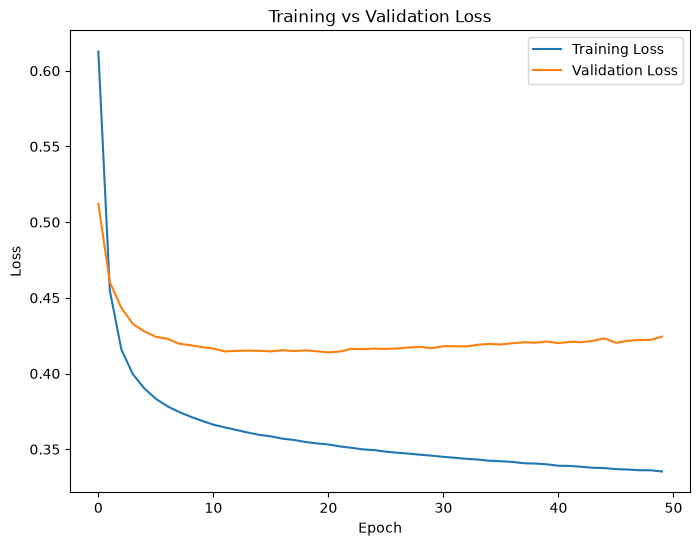

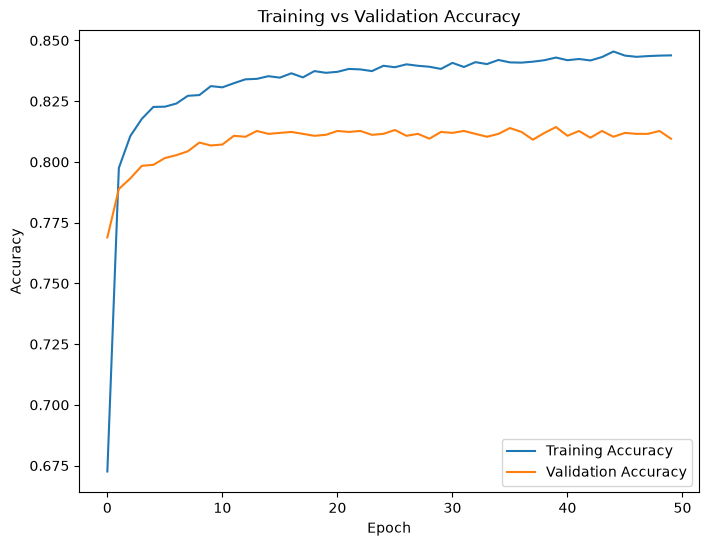

In [61]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [62]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels
nn_pred_probs = nn_model.predict(X_test_scaled)
nn_y_pred = (nn_pred_probs > 0.5).astype(int).flatten()


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [63]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE

# Compute accuracy and F1 score for the neural network and print the results
nn_accuracy = accuracy_score(y_test, nn_y_pred)
nn_f1 = f1_score(y_test, nn_y_pred, pos_label=1)
nn_auc = roc_auc_score(y_test, nn_pred_probs)

print(f"Neural Network Accuracy: {nn_accuracy:.3f}")
print(f"Neural Network F1 Score: {nn_f1:.3f}")
print(f"Neural Network AUC Score: {nn_auc:.3f}") # was 0.905

Neural Network Accuracy: 0.813
Neural Network F1 Score: 0.687
Neural Network AUC Score: 0.906


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. 
    - The network uses two hidden layers, with 32 units in the first layer and 16 units in the second, both using ReLU activation. ReLU was chosen because it avoids the vanishing gradient issues older activation functions like sigmoid can run into. Narrowing from 32 units down to 16 follows a common design pattern that gradually compresses what the network has learned before making a final prediction. The output layer uses a single unit with sigmoid activation, which is the standard choice for binary classification since it produces a probability between zero and one.

    - For training, I used stochastic gradient descent with a learning rate of 0.01, a common middle ground that is high enough to make steady progress each epoch without becoming unstable. I trained for 50 epochs. I initially tested 100 epochs as well, but the validation curves showed that training longer actually hurt generalization, so 50 epochs turned out to be the better choice. 

2. The curves point to mild overfitting rather than underfitting. Training loss decreases steadily across all fifty epochs, while validation loss drops quickly at first, then flattens out after roughly epoch ten and stays fairly constant for the rest of training. The accuracy plot shows the same pattern: training accuracy keeps climbing the whole time, while validation accuracy flattens early and holds steady. There is a growing gap, training performance still improves while validation stalls, showing mild overfitting.

3. On the test set, the neural network reached an accuracy of 0.810 and an F1 score of 0.687. This was not surprising given the training curves, since validation accuracy had already settled around 0.805 to 0.810 by the later epochs, so the test result lines up closely with what the model was already showing during training. Compared to the tuned logistic regression model, the neural network performed almost identically, suggesting that the added complexity of a neural network did not provide a meaningful advantage for this particular problem.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [65]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE

# Build a side-by-side comparison of your two models using the metric variables
# you created.
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', "AUC"],
    'Logistic Regression': [final_accuracy, final_f1, final_auc],
    'Neural Network': [nn_accuracy, nn_f1, nn_auc]
})
print(results.to_string(index=False))

  Metric  Logistic Regression  Neural Network
Accuracy             0.807462        0.813296
F1 Score             0.678791        0.687404
     AUC             0.905180        0.905936


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. The neural network performed slightly better than logistic regression on both metrics, though the gap is small. Accuracy went from about 0.807 to about 0.810, and F1 score went from about 0.679 to about 0.687. Nothing got worse. That said, this comparison is based on a single run of the neural network, while logistic regression was tested and shown to be stable across three different test splits earlier in this project.

2. Given how marginal the improvement was, the added complexity is hard to justify here. The neural network took longer to train, required more decisions to tune such as the number of layers, units, learning rate, and epochs, and its predictions are much harder to interpret than a logistic regression model's coefficients. For a gain of roughly one percentage point in accuracy, that tradeoff does not seem worthwhile for this particular problem.

3. I would recommend deploying the logistic regression model. Performance between the two models is essentially the same, so the deciding factors come down to interpretability, training cost, and accountability. In a lending context, being able to explain why a model made a particular prediction matters a great deal, both for internal review and because credit decisions often carry legal requirements to provide specific reasons for a denial. Logistic regression coefficients make this straightforward, since we were able to directly show which features increased or decreased the predicted likelihood of higher income earlier in this project. A neural network does not offer that same transparency without extra tooling. Logistic regression is also faster and cheaper to train and retrain over time, which matters for a business that would need to update this model as new data comes in.

4. With more time, I would try a few specific things. First, I would compare oversampling techniques like SMOTE against the undersampling approach used here, since undersampling discarded a large portion of the majority class training data. Second, I would add an early stopping callback to the neural network so the ideal number of epochs is found automatically rather than chosen by hand. Third, I would run a proper hyperparameter search for the neural network, similar to the grid search done for logistic regression, testing different numbers of layers, units, and learning rates. Fourth, I would evaluate both models' error rates broken down by race, sex, and native country specifically, rather than in aggregate, to check directly for disparate impact rather than relying on proxy correlation analysis alone. 

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

<Double click this Markdown cell to make it editable, and record your answers here.>

1. To be honest, I used Claude throughout nearly every stage of this capstone. I wrote out my own reasoning and steps for the project, and understood each step before moving forward. Using Claude made me significantly faster at coding, debugging, and understanding why certain choices made sense.

2. The EDA and data preparation were the most challenging. It was difficult knowing what plots to use to show relationships given how many variables I had to visualize, and what columns were worth dropping. It was also hard to decide how to balance the label for training without letting that decision cause other issues. One example of a prompt that did not land immediately involved a bug in my missing value handling code. A 37.0 value had unexpectedly appeared across three of my categorical columns after I filled in missing values using a mode based approach. My first hypothesis, checking for NaN values directly, turned out to be wrong, since a null check came back completely clean. It took a few more rounds of investigation, checking for mixed data types and then the actual float values present, before we traced it back to a bug in how I was calculating the mode for imputation. That process took several exchanges to work through, but it taught me to verify assumptions step by step instead of trusting that a fix worked just because no error was thrown. 


3. I verified my work in a few concrete ways rather than just trusting that the code ran without errors. I checked ```df.info()``` and column data types directly instead of assuming a column was clean, which is what caught the missing value bug described above. I also cross checked results against each other, for example confirming that my neural network's final test accuracy and F1 score were consistent with what the validation curves had already shown during training, rather than being surprised by a mismatch. Beyond that, I read through the code Claude gave me line by line and asked follow up questions any time I did not fully understand why a particular approach was correct, so I could confirm the reasoning matched the implementation rather than just accepting the output.

4. I would apply the same rigor I used for logistic regression to the neural network, for example running a proper hyperparameter search and adding early stopping instead of manually picking the number of epochs. I would also check model performance broken down by subgroups like race, sex, and native country directly, rather than relying only on proxy correlation analysis, to get a more direct read on fairness. I would also keep using Claude going forward, since it made me faster without replacing my own understanding of what the code was doing.